# **Baseline**
 A standard CNN processing the raw image to predict the scene label/embedding, ignoring the explicit graph structure.

CNN -> enbendigs -> contrastive loss

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.datasets.datasets import SceneDataset, get_dataloader
from torchvision import transforms

# Con backbone ImageNet pre-trained, serve la normalizzazione ImageNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

 ## Dataloader

In [3]:
from torch.utils.data import DataLoader
import pandas as pd

df_train = pd.read_csv("../data/df_train.csv")
df_val = pd.read_csv("../data/df_val.csv")

all_labels = df_train["labels"].unique()

label2idx = {l: i for i, l in enumerate(all_labels)}
idx2label = {i: l for l, i in label2idx.items()}

dataset_tr = SceneDataset(
    df_train,
    "../data/images",
    label2idx=label2idx,
    transform=transform
)

dataset_val = SceneDataset(
    df_val,
    "../data/images",
    label2idx=label2idx,
    transform=transform
)

loader_train  = get_dataloader(dataset_tr)

In [4]:
from src.models.baseline import EmbeddingNet

## Training Loop

In [5]:
import torch
from torch.optim import Adam
import matplotlib.pyplot as plt
import os
from src.training.train_model import train_model
from src.training.contrastiveloss import supervised_contrastive_loss

device = "cuda" if torch.cuda.is_available() else "cpu"
model = EmbeddingNet(dim=128, pretrained=True).to(device)
optimizer = Adam(model.parameters(), lr=1e-4)

epochs = 10
loss_history = []

In [7]:

model, loss_history = train_model(
    model=EmbeddingNet(dim=128, pretrained=True),
    loader=loader_train,
    loss_fn=lambda emb, labels: supervised_contrastive_loss(emb, labels, temperature=0.1),
    device=device,
    epochs=epochs,
    lr=1e-4,
    save_path=os.path.abspath("..") + f"/experiments/checkpoints/baseline{epochs}.pth"
)

Epoch 1/10 - loss: 2.0857
Epoch 2/10 - loss: 1.7630
Epoch 3/10 - loss: 1.6235
Epoch 4/10 - loss: 1.5249
Epoch 5/10 - loss: 1.4514
Epoch 6/10 - loss: 1.4234
Epoch 7/10 - loss: 1.3816
Epoch 8/10 - loss: 1.3494
Epoch 9/10 - loss: 1.3285
Epoch 10/10 - loss: 1.3028
Model saved to: p:\Uni\mujoco\dl26-projects/experiments/checkpoints/baseline10.pth


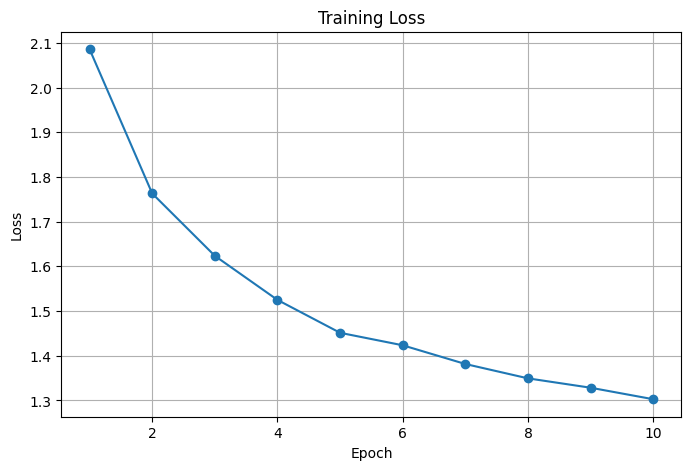

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs + 1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

## Retrival evaluation 

In [6]:
import os
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
baseline_model = EmbeddingNet(dim=128, pretrained=True).to(device)


parent_dir = os.path.abspath("..")
ckpt_path = os.path.join(
    parent_dir,
    "experiments",
    "checkpoints",
    "baseline10.pth"
)

state_dict = torch.load(ckpt_path, map_location=device)
baseline_model.load_state_dict(state_dict)

baseline_model.eval()

EmbeddingNet(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [10]:
from src.evaluation.retrieval import compute_embeddings, evaluate_retrieval, print_metrics, plot_retrieval, plot_tsne

In [8]:
model = baseline_model.to(device)


embeddings, labels = compute_embeddings(
    model=model,
    dataset=dataset_val,      
    device=device,
    batch_size=64,
    num_workers=4,
    normalize=True,           # cosine similarity
)

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)


results, indices, scores = evaluate_retrieval(
    embeddings,
    labels,
    ks=(1, 5, 10),
)


print_metrics(results)

Embeddings shape: torch.Size([3208, 128])
Labels shape: torch.Size([3208])

========== Retrieval Metrics ==========

acc@1               : 0.6213
precision_macro     : 0.5875
recall_macro        : 0.5655
recall@1            : 0.6213
recall@5            : 0.8332
recall@10           : 0.8878
precision@1         : 0.6213
precision@5         : 0.6178
precision@10        : 0.6161
mrr                 : 0.7131
map                 : 0.6784



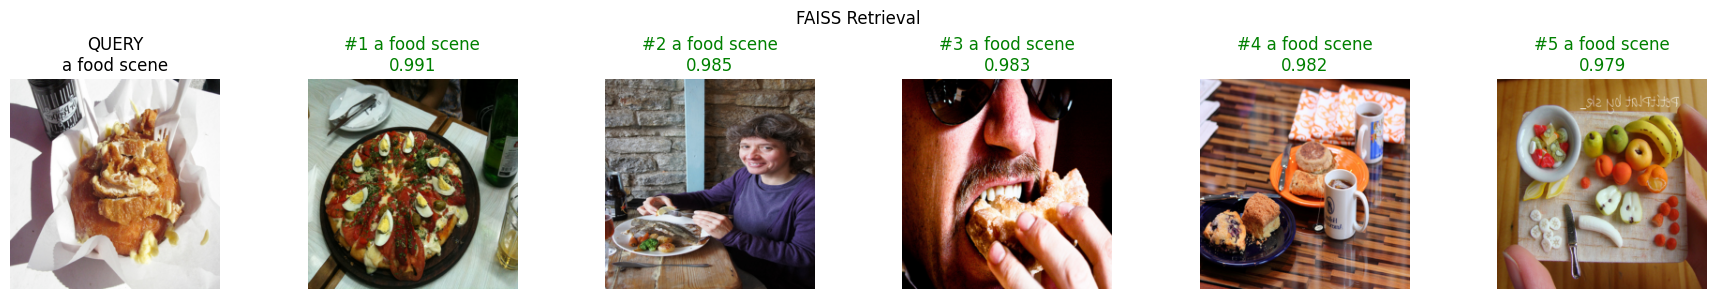

In [9]:
query_idx = 10

plot_retrieval(
    dataset=dataset_val,
    labels=labels,
    indices=indices,
    scores=scores,
    query_idx=query_idx,
    idx2label=dataset_val.idx2label,
    topk=5,
    title="FAISS Retrieval",
)

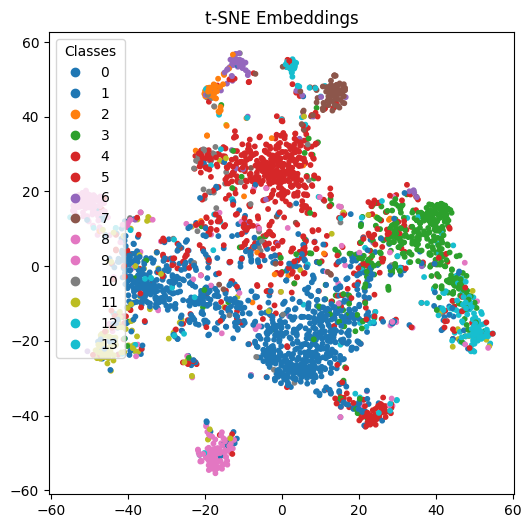

In [11]:
plot_tsne(
    embeddings=embeddings,
    labels=labels
          )